In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ecg-data/mitbih_test.csv
/kaggle/input/ecg-data/mitbih_train.csv


In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, LSTM, Bidirectional, Dense, Dropout
)
from tensorflow.keras.optimizers import Adam


2026-03-07 05:42:24.809099: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772862145.002568      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772862145.060594      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772862145.561158      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772862145.561231      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772862145.561234      23 computation_placer.cc:177] computation placer alr

In [3]:
df = pd.read_csv("/kaggle/input/ecg-data/mitbih_train.csv", header=None)

print(df.shape)   # should be (87554, 188)


(87554, 188)


In [4]:
X = df.iloc[:, :-1].values    # shape: (samples, 187)
y = df.iloc[:, -1].values    # shape: (samples,)


In [5]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))


X shape: (87554, 187)
y shape: (87554,)
Unique labels: [0. 1. 2. 3. 4.]


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [7]:
def moving_average(signal, window=5):
    return np.convolve(signal, np.ones(window)/window, mode="same")

def create_ts_channels(signal):
    original = signal
    smooth = moving_average(signal)
    derivative = np.gradient(signal)

    # normalize each channel
    def norm(x):
        return (x - np.mean(x)) / (np.std(x) + 1e-8)

    return np.stack([
        norm(original),
        norm(smooth),
        norm(derivative)
    ], axis=1)


In [8]:
X_train_ts = np.array([create_ts_channels(x) for x in X_train])
X_val_ts   = np.array([create_ts_channels(x) for x in X_val])

print(X_train_ts.shape)


(70043, 187, 3)


In [9]:
print("X_train_ts shape:", X_train_ts.shape)
print("y_train shape:", y_train.shape)


X_train_ts shape: (70043, 187, 3)
y_train shape: (70043,)


In [10]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

# soften weights (VERY IMPORTANT)
class_weight_dict = {
    int(cls): float(wt ** 0.5)
    for cls, wt in zip(np.unique(y_train), class_weights)
}

print("Class weights:", class_weight_dict)


Class weights: {0: 0.49155203425853494, 1: 2.8069293976549488, 2: 1.7394296624916856, 3: 5.2256303424212405, 4: 1.6500787742187668}


In [11]:
model = Sequential([
    Input(shape=(187, 3)),

    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),

    Bidirectional(LSTM(64)),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dense(5, activation="softmax")
])


I0000 00:00:1772862181.264614      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [12]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 187, 128)       │        34,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 187, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,213 (555.52 KB)

 Trainable params: 142,213 (555.52 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train_ts, y_train,
    validation_data=(X_val_ts, y_val),
    epochs=20,
    batch_size=128,
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/20


I0000 00:00:1772862187.839212      66 cuda_dnn.cc:529] Loaded cuDNN version 91002


548/548 ━━━━━━━━━━━━━━━━━━━━ 35s 52ms/step - accuracy: 0.8761 - loss: 0.5709 - val_accuracy: 0.9499 - val_loss: 0.2011
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.9403 - loss: 0.2730 - val_accuracy: 0.9534 - val_loss: 0.1606
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.9490 - loss: 0.2159 - val_accuracy: 0.9517 - val_loss: 0.1768
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.9553 - loss: 0.1900 - val_accuracy: 0.9601 - val_loss: 0.1398
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.9613 - loss: 0.1596 - val_accuracy: 0.9571 - val_loss: 0.1449
Epoch 6/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.9643 - loss: 0.1443 - val_accuracy: 0.9553 - val_loss: 0.1464
Epoch 7/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 27s 50ms/step - accuracy: 0.9650 - loss: 0.1390 - val_accuracy: 0.9729 - val_loss: 0.0912
Epoch 8/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 27s 50ms/step - accuracy: 0.9693 - loss: 0.1212 - val_accurac

In [14]:
y_pred = np.argmax(model.predict(X_val_ts), axis=1)

print(classification_report(y_val, y_pred))


548/548 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     14494
         1.0       0.83      0.88      0.86       445
         2.0       0.94      0.97      0.95      1158
         3.0       0.64      0.86      0.73       128
         4.0       0.99      0.99      0.99      1286

    accuracy                           0.98     17511
   macro avg       0.88      0.94      0.90     17511
weighted avg       0.98      0.98      0.98     17511



In [15]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Layer, Input, LSTM, Bidirectional,
    Dense, Dropout
)
from tensorflow.keras.models import Model


In [16]:
class TemporalAttention(Layer):
    def __init__(self):
        super().__init__()

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="normal"
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros"
        )

    def call(self, x):
        # x shape: (batch, timesteps, features)
        e = tf.tanh(tf.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)      # attention weights
        output = tf.reduce_sum(x * a, axis=1)
        return output, a


In [17]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D

inputs = Input(shape=(187, 3))

# NEW CNN block
x = Conv1D(32, kernel_size=5, activation='relu', padding='same')(inputs)
x = MaxPooling1D(pool_size=2)(x)

x = Bidirectional(LSTM(64, return_sequences=True))(x)


# BiLSTM encoder
x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.3)(x)

# Attention
context, attention_weights = TemporalAttention()(x)

# Dense layers
x = Dense(64, activation="relu")(context)
outputs = Dense(5, activation="softmax")(x)

model_att = Model(inputs, outputs)


In [18]:
import tensorflow as tf

def focal_loss(alpha, gamma=2.0):
    alpha = tf.constant(list(alpha.values()), dtype=tf.float32)

    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_onehot = tf.one_hot(y_true, depth=5)

        pt = tf.reduce_sum(y_true_onehot * y_pred, axis=-1)
        at = tf.reduce_sum(y_true_onehot * alpha, axis=-1)

        return -at * tf.pow(1. - pt, gamma) * tf.math.log(pt + 1e-8)

    return loss


In [19]:
model_att.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=focal_loss(class_weight_dict, gamma=2.0),
    metrics=["accuracy"]
)

model_att.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 187, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 187, 128)       │        34,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 187, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 187, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 187, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ [(None, 128), (None,   │           315 │
│ (TemporalAttention)             │ 187, 1)]               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,528 (556.75 KB)

 Trainable params: 142,528 (556.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
def augment(signal):
    noise = np.random.normal(0, 0.01, signal.shape)
    scale = np.random.uniform(0.9, 1.1)
    return signal * scale + noise

X_aug = []
y_aug = []

for x, label in zip(X_train_ts, y_train):
    if label in [1, 3]:  # minority classes
        X_aug.append(augment(x))
        y_aug.append(label)

X_train_ts = np.concatenate([X_train_ts, np.array(X_aug)])
y_train = np.concatenate([y_train, np.array(y_aug)])


In [21]:
history_att = model_att.fit(
    X_train_ts, y_train,
    validation_data=(X_val_ts, y_val),
    epochs=30,
    batch_size=128,
    verbose=1
)


Epoch 1/30
566/566 ━━━━━━━━━━━━━━━━━━━━ 35s 54ms/step - accuracy: 0.8178 - loss: 0.4251 - val_accuracy: 0.9294 - val_loss: 0.1115
Epoch 2/30
566/566 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step - accuracy: 0.9082 - loss: 0.1366 - val_accuracy: 0.9403 - val_loss: 0.0802
Epoch 3/30
566/566 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9301 - loss: 0.1002 - val_accuracy: 0.9553 - val_loss: 0.0673
Epoch 4/30
566/566 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9394 - loss: 0.0820 - val_accuracy: 0.9468 - val_loss: 0.0610
Epoch 5/30
566/566 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9428 - loss: 0.0743 - val_accuracy: 0.9203 - val_loss: 0.0653
Epoch 6/30
566/566 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9443 - loss: 0.0663 - val_accuracy: 0.9380 - val_loss: 0.0561
Epoch 7/30
566/566 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9408 - loss: 0.0721 - val_accuracy: 0.9543 - val_loss: 0.0500
Epoch 8/30
566/566 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9507 - loss: 0.0594 - 

In [22]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

model.fit(X_train_ts, y_train, class_weight=class_weights)


2261/2261 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.8775 - loss: 0.2867


In [23]:
y_pred = tf.argmax(model_att.predict(X_val_ts), axis=1).numpy()

from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred))


548/548 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99     14494
         1.0       0.72      0.90      0.80       445
         2.0       0.95      0.96      0.95      1158
         3.0       0.54      0.90      0.67       128
         4.0       0.98      0.99      0.99      1286

    accuracy                           0.98     17511
   macro avg       0.84      0.95      0.88     17511
weighted avg       0.98      0.98      0.98     17511



In [24]:
attention_model = Model(
    inputs=model_att.input,
    outputs=attention_weights
)


In [25]:
attention_model.save("ecg_attention_extractor.h5")

In [26]:
idx = 10  # try different classes
att_weights = attention_model.predict(
    X_val_ts[idx:idx+1]
)[0].squeeze()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step


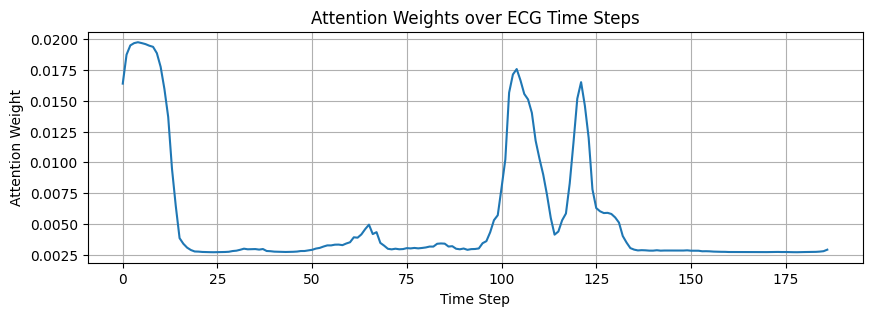

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
plt.plot(att_weights)
plt.title("Attention Weights over ECG Time Steps")
plt.xlabel("Time Step")
plt.ylabel("Attention Weight")
plt.grid()
plt.savefig("attention_weights_over_ecg_time_steps.png", dpi=300, bbox_inches="tight")
plt.show()



In [28]:
x_sample = X_val_ts[0:1]     # shape (1, 187, 3)

# Get predicted class
pred = model_att(x_sample)
target_class = tf.argmax(pred[0])

In [29]:
import tensorflow as tf

# 1️⃣ Make sure input is a Tensor
x_sample = tf.convert_to_tensor(X_val_ts[0:1], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(x_sample)

    # 2️⃣ Forward pass
    preds = model_att(x_sample)

    # 3️⃣ Choose target class INSIDE the tape
    target_class = tf.argmax(preds[0])

    # 4️⃣ Select scalar loss
    loss = preds[:, target_class]

# 5️⃣ Compute gradients
grads = tape.gradient(loss, x_sample)

print(grads.shape)  # (1, 187, 3)


(1, 187, 3)


In [30]:
saliency = tf.abs(grads)[0]        # (187, 3)
saliency_1d = tf.reduce_mean(saliency, axis=1)  # (187,)
saliency_1d = saliency_1d.numpy()


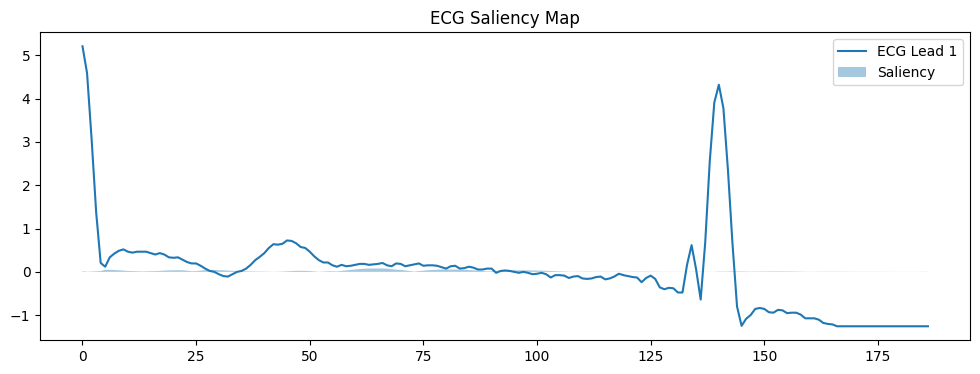

In [31]:
import matplotlib.pyplot as plt

time = np.arange(187)

plt.figure(figsize=(12,4))
plt.plot(time, x_sample[0,:,0], label="ECG Lead 1")
plt.fill_between(time, saliency_1d, alpha=0.4, label="Saliency")
plt.legend()
plt.title("ECG Saliency Map")
plt.savefig("ecg_saliency_map.png", dpi=300, bbox_inches="tight")
plt.show()



In [32]:
baseline = tf.zeros_like(x_sample)  # shape (1, 187, 3)
def integrated_gradients(
    model,
    x,
    baseline,
    target_class,
    steps=50
):
    """
    model: trained keras model
    x: input tensor (1, T, C)
    baseline: baseline tensor (1, T, C)
    target_class: class index tensor
    steps: number of integration steps
    """

    # 1️⃣ Generate scaled inputs
    alphas = tf.linspace(0.0, 1.0, steps+1)

    integrated_grads = tf.zeros_like(x)

    for alpha in alphas:
        x_interp = baseline + alpha * (x - baseline)

        with tf.GradientTape() as tape:
            tape.watch(x_interp)
            preds = model(x_interp, training=False)
            loss = preds[:, target_class]

        grads = tape.gradient(loss, x_interp)
        integrated_grads += grads

    # 2️⃣ Average gradients and scale
    integrated_grads /= tf.cast(steps + 1, tf.float32)
    integrated_grads *= (x - baseline)

    return integrated_grads


In [33]:
# Make sure input is a tensor
x_sample = tf.convert_to_tensor(X_val_ts[0:1], dtype=tf.float32)

# Get prediction & target class
preds = model_att(x_sample, training=False)
target_class = tf.argmax(preds[0])

# Compute Integrated Gradients
ig = integrated_gradients(
    model=model_att,
    x=x_sample,
    baseline=baseline,
    target_class=target_class,
    steps=50
)


In [34]:
ig_abs = tf.abs(ig)[0]                 # (187, 3)
ig_time = tf.reduce_mean(ig_abs, axis=1)  # (187,)


In [35]:
ig_channel = tf.reduce_mean(ig_abs, axis=0)
print("Channel importance:", ig_channel.numpy())


Channel importance: [0.00257313 0.0027061  0.00996294]


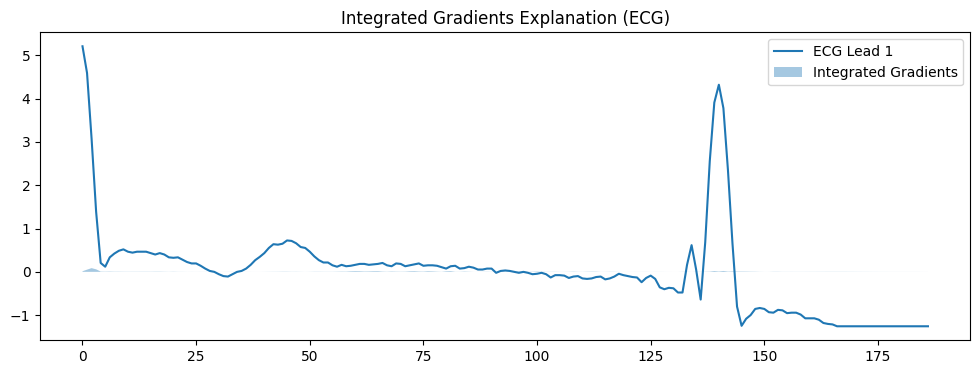

In [36]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(187)

plt.figure(figsize=(12,4))
plt.plot(time, x_sample[0,:,0], label="ECG Lead 1")
plt.fill_between(time, ig_time.numpy(), alpha=0.4, label="Integrated Gradients")
plt.legend()
plt.title("Integrated Gradients Explanation (ECG)")
plt.savefig("integrated_gradients_ecg.png", dpi=300, bbox_inches="tight")
plt.show()



In [37]:
# Get attention weights
attention_model = tf.keras.Model(
    inputs=model_att.input,
    outputs=attention_weights
)

attn = attention_model(x_sample).numpy().squeeze()  # (187,)

# Attention-weighted IG
ig_weighted = ig_time.numpy() * attn


In [38]:
import numpy as np
saliency_1d = np.array(saliency_1d)
saliency_norm = saliency_1d / (saliency_1d.max() + 1e-8)

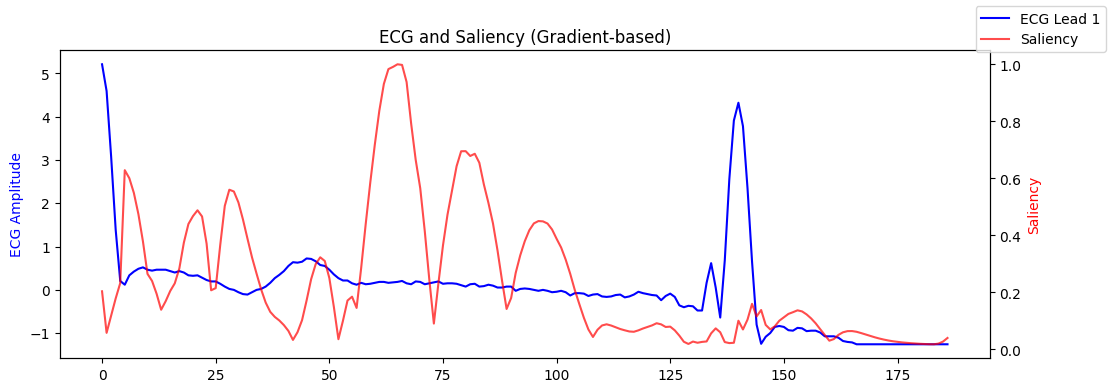

In [39]:
fig, ax1 = plt.subplots(figsize=(12,4))

# ECG
ax1.plot(time, x_sample[0,:,0], color="blue", label="ECG Lead 1")
ax1.set_ylabel("ECG Amplitude", color="blue")

# Saliency
ax2 = ax1.twinx()
ax2.plot(time, saliency_norm, color="red", alpha=0.7, label="Saliency")
ax2.set_ylabel("Saliency", color="red")

fig.legend(loc="upper right")
plt.title("ECG and Saliency (Gradient-based)")
plt.savefig("ecg_saliency_overlay.png", dpi=300, bbox_inches="tight")
plt.show()



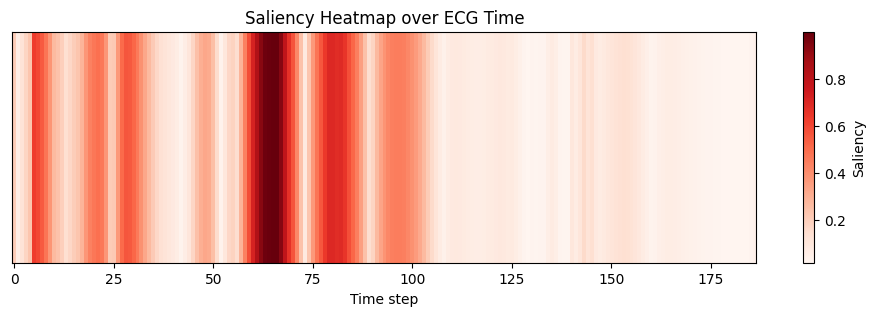

In [40]:
plt.figure(figsize=(12,3))
plt.imshow(
    saliency_norm[np.newaxis, :],
    aspect="auto",
    cmap="Reds"
)
plt.yticks([])
plt.xlabel("Time step")
plt.title("Saliency Heatmap over ECG Time")
plt.colorbar(label="Saliency")
plt.savefig("saliency_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()



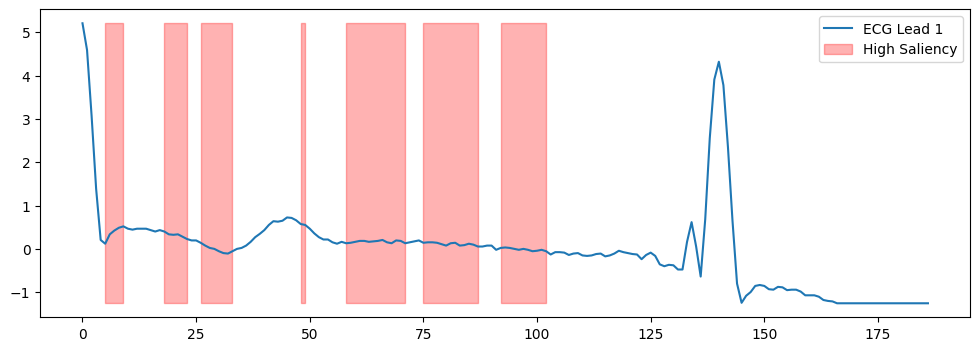

In [41]:
saliency_norm = saliency_1d / (saliency_1d.max() + 1e-8)

plt.figure(figsize=(12,4))
plt.plot(time, x_sample[0,:,0], label="ECG Lead 1")

plt.fill_between(
    time,
    y1=min(x_sample[0,:,0]),
    y2=max(x_sample[0,:,0]),
    where=saliency_norm > 0.3,
    color="red",
    alpha=0.3,
    label="High Saliency"
)

plt.legend()
plt.savefig("ecg_saliency_highlighted.png", dpi=300, bbox_inches="tight")
plt.show()



In [42]:
test_df = pd.read_csv("/kaggle/input/ecg-data/mitbih_test.csv", header=None)

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print("Raw Test Shape:", X_test.shape)


X_test_ts = np.array([create_ts_channels(x) for x in X_test])
print("Processed Test Shape:", X_test_ts.shape)



y_pred_test = np.argmax(model_att.predict(X_test_ts), axis=1)



from sklearn.metrics import classification_report, confusion_matrix

print("\n=== Classification Report (TEST SET) ===")
print(classification_report(y_test, y_pred_test))

print("\n=== Confusion Matrix (TEST SET) ===")
print(confusion_matrix(y_test, y_pred_test))

Raw Test Shape: (21892, 187)
Processed Test Shape: (21892, 187, 3)
685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step

=== Classification Report (TEST SET) ===
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99     18118
         1.0       0.69      0.85      0.76       556
         2.0       0.95      0.95      0.95      1448
         3.0       0.58      0.90      0.70       162
         4.0       0.98      0.99      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.84      0.93      0.88     21892
weighted avg       0.98      0.98      0.98     21892


=== Confusion Matrix (TEST SET) ===
[[17779   205    42    72    20]
 [   69   475     9     2     1]
 [   32     7  1374    31     4]
 [    8     0     9   145     0]
 [    7     0     6     1  1594]]


In [43]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D

cnn_model = Sequential([
    Input(shape=(187,3)),

    Conv1D(32,5,activation="relu",padding="same"),
    MaxPooling1D(2),

    Conv1D(64,5,activation="relu",padding="same"),
    MaxPooling1D(2),

    Conv1D(128,3,activation="relu",padding="same"),
    GlobalAveragePooling1D(),

    Dense(64,activation="relu"),
    Dropout(0.3),
    Dense(5,activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [44]:
cnn_model.fit(
    X_train_ts, y_train,
    validation_data=(X_val_ts, y_val),
    epochs=20,
    batch_size=128
)

Epoch 1/20


I0000 00:00:1772863800.818604      65 service.cc:152] XLA service 0x7ff5da14e360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772863800.818645      65 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


 40/566 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7439 - loss: 1.0897

I0000 00:00:1772863804.303781      65 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


566/566 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8214 - loss: 0.6642 - val_accuracy: 0.9351 - val_loss: 0.2488
Epoch 2/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9162 - loss: 0.2946 - val_accuracy: 0.9535 - val_loss: 0.1787
Epoch 3/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9389 - loss: 0.2201 - val_accuracy: 0.9535 - val_loss: 0.1902
Epoch 4/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9455 - loss: 0.1993 - val_accuracy: 0.9662 - val_loss: 0.1207
Epoch 5/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9531 - loss: 0.1684 - val_accuracy: 0.9668 - val_loss: 0.1242
Epoch 6/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9552 - loss: 0.1615 - val_accuracy: 0.9709 - val_loss: 0.1014
Epoch 7/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9577 - loss: 0.1497 - val_accuracy: 0.9655 - val_loss: 0.1174
Epoch 8/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9594 - loss: 0.1450 - val_accuracy: 0.9734 - va

In [45]:
inputs = Input(shape=(187,3))

x = Conv1D(32,5,activation="relu",padding="same")(inputs)
x = MaxPooling1D(2)(x)

x = Conv1D(64,3,activation="relu",padding="same")(x)
x = MaxPooling1D(2)(x)

x = LSTM(64)(x)

x = Dense(64,activation="relu")(x)
x = Dropout(0.3)(x)

outputs = Dense(5,activation="softmax")(x)

cnn_lstm = Model(inputs,outputs)

cnn_lstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [46]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization

inputs = Input(shape=(187,3))

x = Dense(64)(inputs)

attn = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(x,x)

x = LayerNormalization()(x + attn)

ff = Dense(128,activation="relu")(x)
ff = Dense(64)(ff)

x = LayerNormalization()(x + ff)

x = tf.keras.layers.GlobalAveragePooling1D()(x)

outputs = Dense(5,activation="softmax")(x)

transformer_model = Model(inputs,outputs)

transformer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [47]:
inputs = Input(shape=(187,3))

x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64))(x)

x = Dense(64,activation="relu")(x)

outputs = Dense(5,activation="softmax")(x)

no_attention_model = Model(inputs,outputs)

no_attention_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [48]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(X_test_ts), axis=1)

print(classification_report(y_test, y_pred))

685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.86      0.92     18118
         1.0       0.25      0.81      0.39       556
         2.0       0.81      0.93      0.86      1448
         3.0       0.15      0.93      0.25       162
         4.0       0.89      0.98      0.93      1608

    accuracy                           0.87     21892
   macro avg       0.62      0.90      0.67     21892
weighted avg       0.95      0.87      0.90     21892



In [49]:
y_prob = model_att.predict(X_test_ts)

y_pred = np.argmax(y_prob, axis=1)

685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step


In [50]:
from sklearn.preprocessing import label_binarize

n_classes = 5

y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])

In [51]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

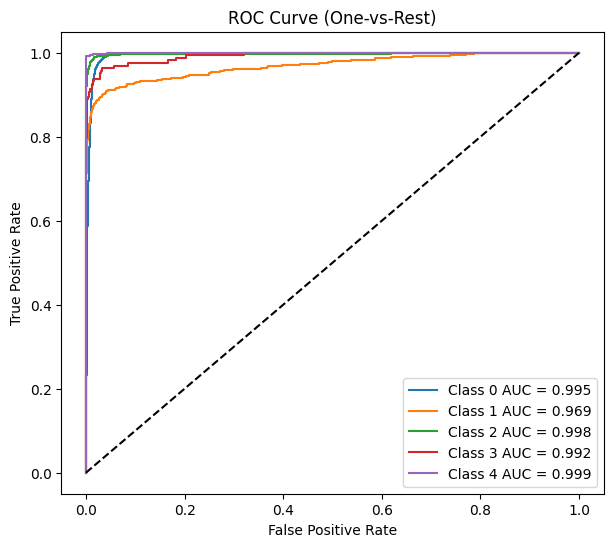

In [52]:
plt.figure(figsize=(7,6))

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Class {i} AUC = {roc_auc[i]:.3f}"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()

plt.savefig("roc_curve_ecg.png", dpi=300)
plt.show()

In [53]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision = dict()
recall = dict()
pr_auc = dict()

for i in range(n_classes):

    precision[i], recall[i], _ = precision_recall_curve(
        y_test_bin[:,i],
        y_prob[:,i]
    )

    pr_auc[i] = average_precision_score(
        y_test_bin[:,i],
        y_prob[:,i]
    )

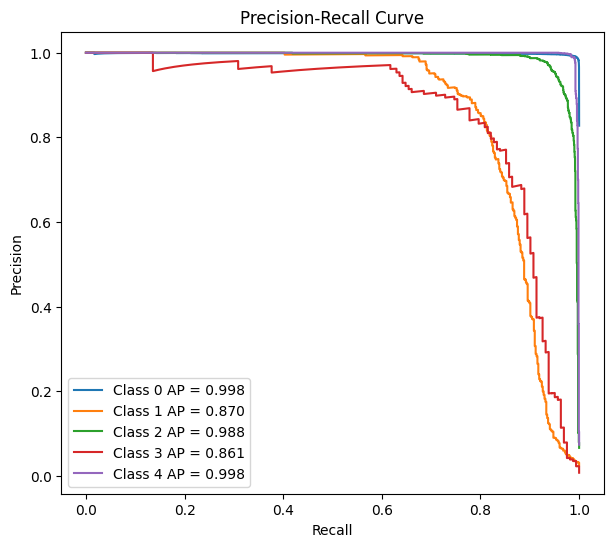

In [54]:
plt.figure(figsize=(7,6))

for i in range(n_classes):

    plt.plot(
        recall[i],
        precision[i],
        label=f"Class {i} AP = {pr_auc[i]:.3f}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()

plt.savefig("pr_curve_ecg.png", dpi=300)
plt.show()

In [55]:
for i in range(n_classes):
    print(f"Class {i} ROC AUC: {roc_auc[i]:.4f}")

Class 0 ROC AUC: 0.9948
Class 1 ROC AUC: 0.9686
Class 2 ROC AUC: 0.9976
Class 3 ROC AUC: 0.9922
Class 4 ROC AUC: 0.9994


In [56]:
for i in range(n_classes):
    print(f"Class {i} PR AUC: {pr_auc[i]:.4f}")

Class 0 PR AUC: 0.9984
Class 1 PR AUC: 0.8703
Class 2 PR AUC: 0.9882
Class 3 PR AUC: 0.8614
Class 4 PR AUC: 0.9978


In [57]:
from sklearn.metrics import roc_auc_score

macro_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class="ovr"
)

print("Macro ROC AUC:", macro_auc)

Macro ROC AUC: 0.990506637060321


In [58]:
def mc_dropout_predictions(model, X, T=50, batch_size=256):

    preds_mc = []

    for t in range(T):

        preds = []

        for i in range(0, len(X), batch_size):

            batch = X[i:i+batch_size]

            pred = model(batch, training=True)

            preds.append(pred.numpy())

        preds = np.concatenate(preds, axis=0)

        preds_mc.append(preds)

    preds_mc = np.array(preds_mc)

    mean_pred = preds_mc.mean(axis=0)
    std_pred = preds_mc.std(axis=0)

    return mean_pred, std_pred

In [59]:
mean_pred, std_pred = mc_dropout_predictions(
    model_att,
    X_test_ts,
    T=30,
    batch_size=256
)

y_pred_mc = np.argmax(mean_pred, axis=1)

In [60]:
sample = 0

print("Prediction probabilities:", mean_pred[sample])
print("Uncertainty (std):", std_pred[sample])

Prediction probabilities: [9.5918220e-01 4.0625136e-02 1.1551578e-04 6.3914100e-05 1.3150595e-05]
Uncertainty (std): [1.6461944e-02 1.6407209e-02 7.5440752e-05 3.9745362e-05 7.1274981e-06]


In [61]:
entropy = -np.sum(mean_pred * np.log(mean_pred + 1e-8), axis=1)

print("Mean entropy:", np.mean(entropy))

Mean entropy: 0.25808653


In [62]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

probs = mean_pred.max(axis=1)
preds = np.argmax(mean_pred, axis=1)

correct = (preds == y_test).astype(int)

prob_true, prob_pred = calibration_curve(
    correct,
    probs,
    n_bins=10
)

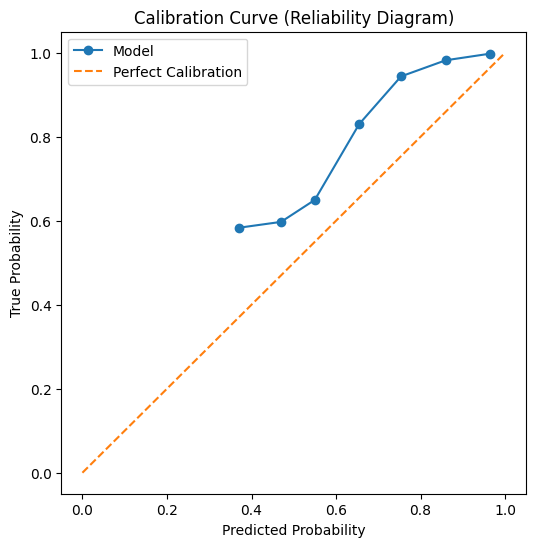

In [63]:
plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve (Reliability Diagram)")
plt.legend()

plt.savefig("calibration_curve.png", dpi=300)
plt.show()

In [64]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(correct, probs)

print("Brier Score:", brier)

Brier Score: 0.024691059778282586


In [65]:
def expected_calibration_error(y_true, probs, n_bins=10):

    bins = np.linspace(0,1,n_bins+1)
    binids = np.digitize(probs, bins) - 1

    ece = 0

    for i in range(n_bins):
        mask = binids == i
        if np.sum(mask) > 0:
            acc = np.mean(y_true[mask])
            conf = np.mean(probs[mask])
            ece += np.abs(acc - conf) * np.sum(mask) / len(y_true)

    return ece

In [66]:
ece = expected_calibration_error(correct, probs)

print("ECE:", ece)

ECE: 0.06097100380241122


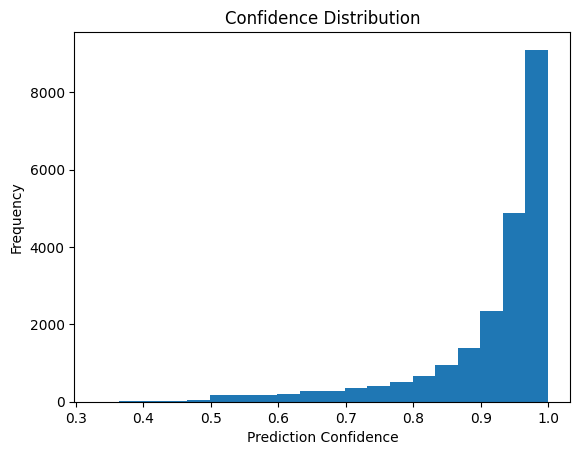

In [67]:
plt.hist(probs, bins=20)
plt.title("Confidence Distribution")
plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.savefig("confidence_histogram.png", dpi=300)
plt.show()

In [68]:
print("BiLSTM+Attention Params:", model_att.count_params())
print("CNN Params:", cnn_model.count_params())
print("CNN-LSTM Params:", cnn_lstm.count_params())
print("Transformer Params:", transformer_model.count_params())
print("BiLSTM (No Attention) Params:", no_attention_model.count_params())

BiLSTM+Attention Params: 142528
CNN Params: 44101
CNN-LSTM Params: 44229
Transformer Params: 50629
BiLSTM (No Attention) Params: 142213


In [69]:
import tensorflow as tf

def get_flops(model):

    concrete = tf.function(lambda x: model(x)).get_concrete_function(
        tf.TensorSpec([1,187,3], tf.float32)
    )

    frozen_func = concrete.graph

    run_meta = tf.compat.v1.RunMetadata()

    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

    flops = tf.compat.v1.profiler.profile(
        graph=frozen_func,
        run_meta=run_meta,
        cmd="op",
        options=opts
    )

    return flops.total_float_ops

In [70]:
print("BiLSTM+Attention FLOPs:", get_flops(model_att))
print("CNN FLOPs:", get_flops(cnn_model))
print("CNN-LSTM FLOPs:", get_flops(cnn_lstm))
print("Transformer FLOPs:", get_flops(transformer_model))

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


BiLSTM+Attention FLOPs:
=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read th

In [71]:
import time

def measure_inference_time(model, X, n_samples=1000):

    X_small = X[:n_samples]

    start = time.time()

    model.predict(X_small, verbose=0)

    end = time.time()

    return (end-start)/n_samples

In [72]:
print("BiLSTM+Attention inference:", measure_inference_time(model_att, X_test_ts))
print("CNN inference:", measure_inference_time(cnn_model, X_test_ts))
print("CNN-LSTM inference:", measure_inference_time(cnn_lstm, X_test_ts))
print("Transformer inference:", measure_inference_time(transformer_model, X_test_ts))

BiLSTM+Attention inference: 0.0006211912631988526
CNN inference: 0.0010474536418914795
CNN-LSTM inference: 0.0005266621112823487
Transformer inference: 0.0016977784633636474


In [73]:
from sklearn.metrics import accuracy_score

def evaluate_model(model, X, y):

    y_pred = np.argmax(model.predict(X), axis=1)

    return accuracy_score(y, y_pred)

In [74]:
print("BiLSTM+Attention accuracy:", evaluate_model(model_att, X_test_ts, y_test))
print("CNN accuracy:", evaluate_model(cnn_model, X_test_ts, y_test))
print("CNN-LSTM accuracy:", evaluate_model(cnn_lstm, X_test_ts, y_test))
print("Transformer accuracy:", evaluate_model(transformer_model, X_test_ts, y_test))

685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step
BiLSTM+Attention accuracy: 0.9760186369450028
685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
CNN accuracy: 0.9778914672026311
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
CNN-LSTM accuracy: 0.0602503197515074
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Transformer accuracy: 0.27612826603325413


In [75]:
import pandas as pd

results = {
    "Model": ["CNN", "CNN-LSTM", "BiLSTM", "BiLSTM+Attention", "Transformer"],
    "Params": [
        cnn_model.count_params(),
        cnn_lstm.count_params(),
        no_attention_model.count_params(),
        model_att.count_params(),
        transformer_model.count_params()
    ],
}

df_results = pd.DataFrame(results)

print(df_results)

              Model  Params
0               CNN   44101
1          CNN-LSTM   44229
2            BiLSTM  142213
3  BiLSTM+Attention  142528
4       Transformer   50629


In [76]:
import numpy as np

def add_noise(signal, noise_std=0.02):
    noise = np.random.normal(0, noise_std, signal.shape)
    return signal + noise

def temporal_shift(signal, max_shift=10):
    shift = np.random.randint(-max_shift, max_shift)
    return np.roll(signal, shift, axis=0)

def amplitude_scale(signal, scale_range=(0.8, 1.2)):
    scale = np.random.uniform(scale_range[0], scale_range[1])
    return signal * scale

In [77]:
X_test_noise = np.array([add_noise(x) for x in X_test_ts])
X_test_shift = np.array([temporal_shift(x) for x in X_test_ts])
X_test_scale = np.array([amplitude_scale(x) for x in X_test_ts])

print("Noise test shape:", X_test_noise.shape)
print("Shift test shape:", X_test_shift.shape)
print("Scale test shape:", X_test_scale.shape)

Noise test shape: (21892, 187, 3)
Shift test shape: (21892, 187, 3)
Scale test shape: (21892, 187, 3)


In [78]:
from sklearn.metrics import accuracy_score

def evaluate(model, X, y):
    y_pred = np.argmax(model.predict(X), axis=1)
    return accuracy_score(y, y_pred)

In [79]:
acc_clean = evaluate(model_att, X_test_ts, y_test)
acc_noise = evaluate(model_att, X_test_noise, y_test)
acc_shift = evaluate(model_att, X_test_shift, y_test)
acc_scale = evaluate(model_att, X_test_scale, y_test)

print("Clean Accuracy:", acc_clean)
print("Noise Accuracy:", acc_noise)
print("Shift Accuracy:", acc_shift)
print("Scale Accuracy:", acc_scale)

685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step
Clean Accuracy: 0.9760186369450028
Noise Accuracy: 0.976475424812717
Shift Accuracy: 0.8552896035081308
Scale Accuracy: 0.9749223460624886


In [80]:
import pandas as pd

robustness_results = pd.DataFrame({
    "Condition": ["Clean", "Noise", "Temporal Shift", "Amplitude Scaling"],
    "Accuracy": [acc_clean, acc_noise, acc_shift, acc_scale]
})

print(robustness_results)

           Condition  Accuracy
0              Clean  0.976019
1              Noise  0.976475
2     Temporal Shift  0.855290
3  Amplitude Scaling  0.974922


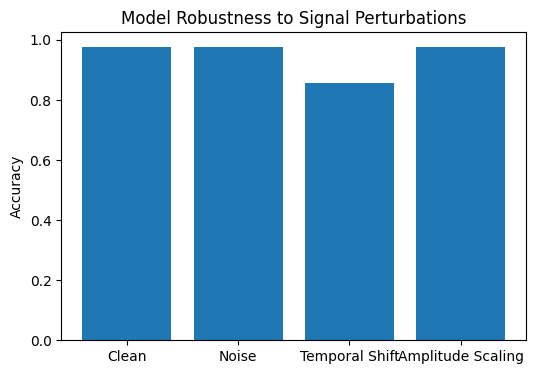

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    robustness_results["Condition"],
    robustness_results["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model Robustness to Signal Perturbations")

plt.savefig("robustness_analysis.png", dpi=300)

plt.show()